In [5]:
import numpy as np
from PIL import Image
from tkinter import Tk, filedialog

root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select the image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp"),
        ("All files", "*.*")
    ]
)

image = Image.open(image_path).convert('L')

print('Image loaded:', image.size, image.mode)
print('Image file:', image_path)

Image loaded: (643, 642) L
Image file: C:/Users/HP/Pictures/Screenshot 2026-09-09 084225.png


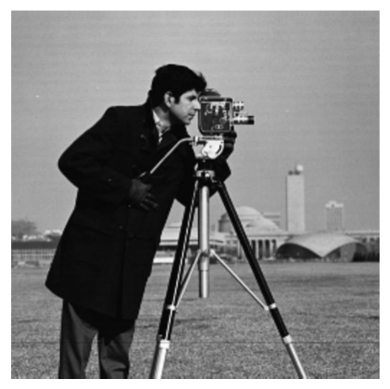

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(r"C:\Users\HP\Downloads\cameraman.png")

plt.imshow(img, cmap="gray")
plt.axis("off") 
plt.show()

In [17]:
width, height = image.size

scale_x = 2
scale_y = 2
print(f'Original size: {width} x {height}')

Original size: 643 x 642


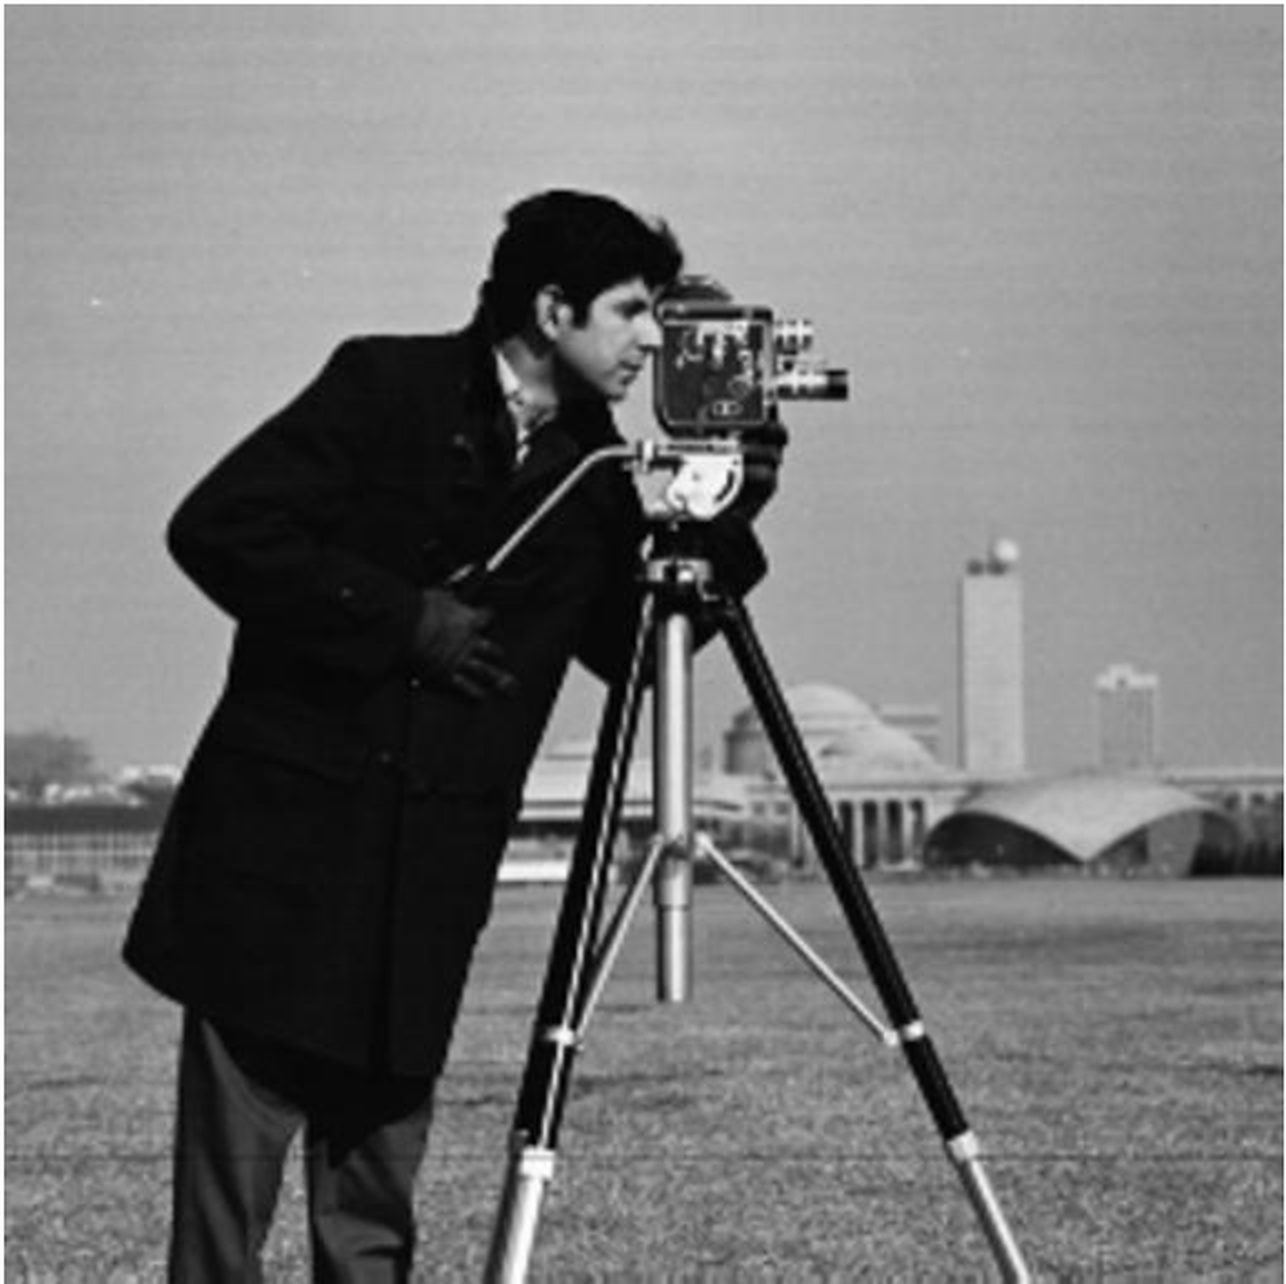

In [18]:
scaled = image.resize((width * scale_x, height * scale_y), Image.Resampling.LANCZOS)
scaled

In [19]:
scaled.save('task1_1_scaled.jpg')
print('Original size:', image.size)
print('Scaled size:', scaled.size)

Original size: (643, 642)
Scaled size: (1286, 1284)


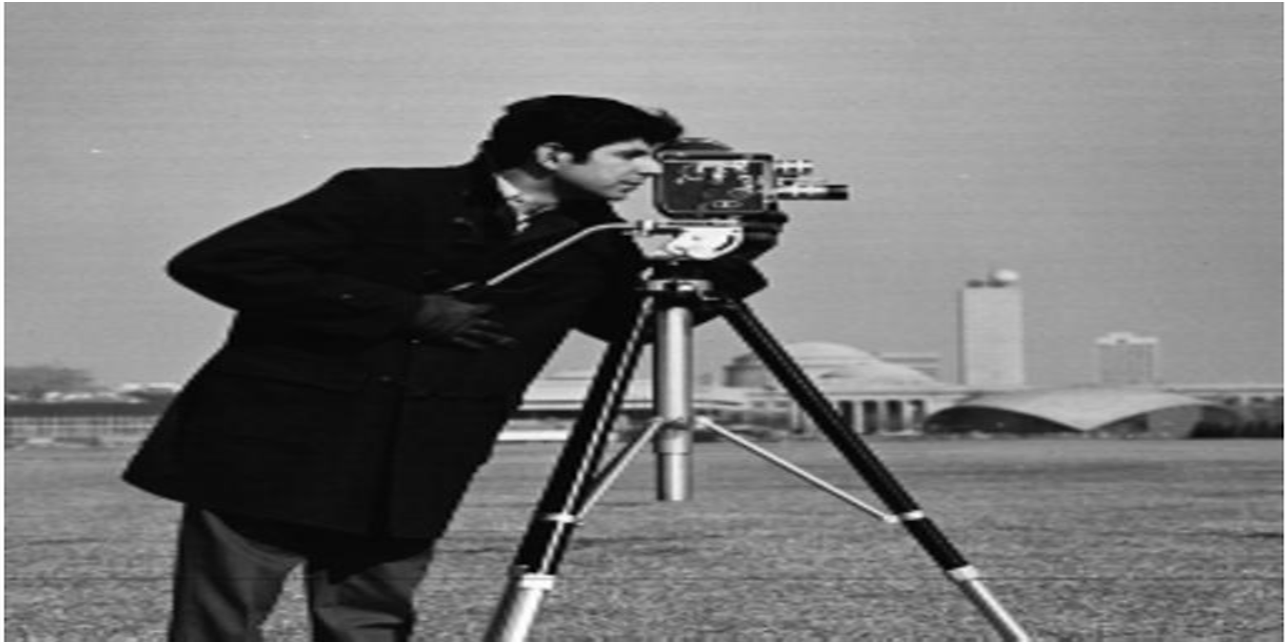

In [20]:
non_uniform = image.resize((width * 2, height), Image.Resampling.LANCZOS)
non_uniform

In [21]:
non_uniform.save('task1_1_nonuniform_scaled.jpg')
print('Original size:', image.size)
print('Non-uniform scaled size:', non_uniform.size)

Original size: (643, 642)
Non-uniform scaled size: (1286, 642)


In [22]:
print('Horizontal stretching factor: 2')
print('Vertical stretching factor: 1')

Horizontal stretching factor: 2
Vertical stretching factor: 1


Original size: (643, 642)
Rotated size: (879, 878)


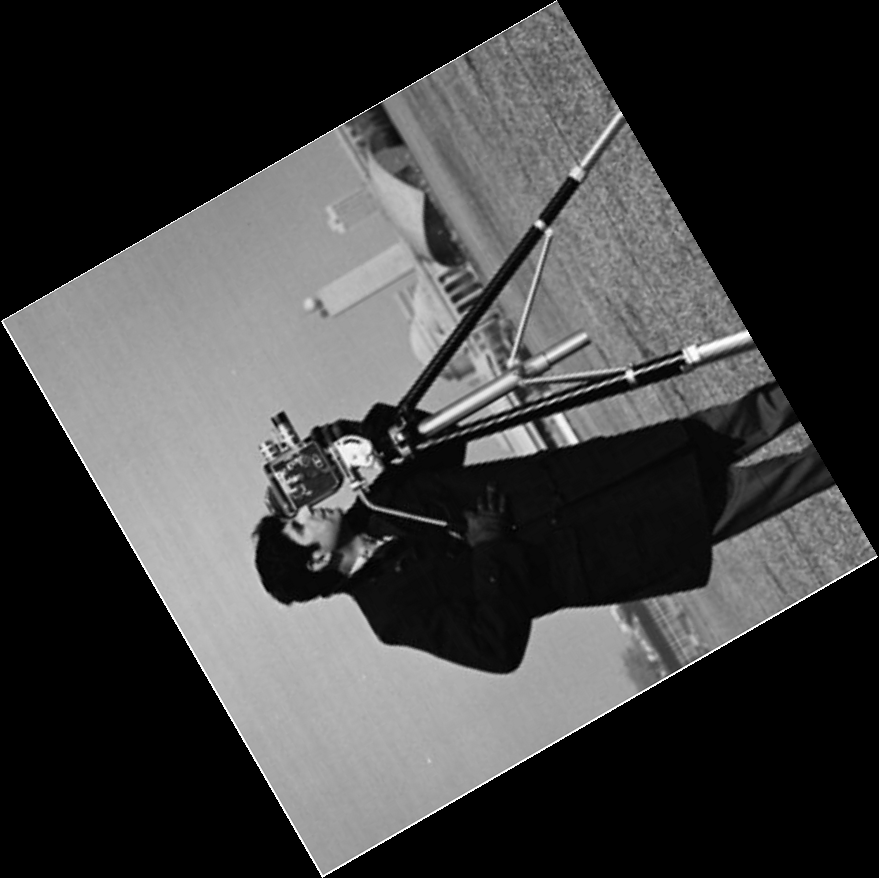

In [23]:
rotated = image.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
rotated.save('task1_2_rotated.jpg')
print('Original size:', image.size)
print('Rotated size:', rotated.size)
rotated

In [24]:
w, h = image.size
print('Image dimensions:', w, 'x', h)

Image dimensions: 643 x 642


In [25]:
shx = 0.5
shy = 0.0

shear_matrix = (1, -shx, 0, 0, 1, 0)

shear_w = int(w + abs(shx) * h)
shear_h = h
print('Shear factor:', shx)
print('Output canvas:', shear_w, 'x', shear_h)

Shear factor: 0.5
Output canvas: 964 x 642


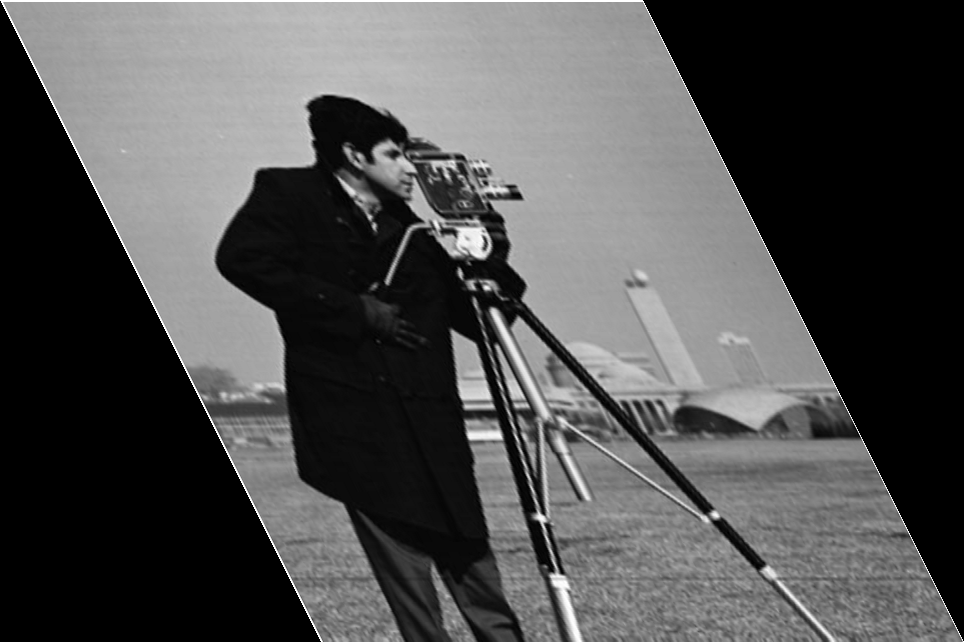

In [26]:
sheared = image.transform(
    (shear_w, shear_h),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)
sheared

In [27]:
sheared.save('task1_3_sheared.jpg')
print('Sheared image saved as task1_3_sheared.jpg')

Sheared image saved as task1_3_sheared.jpg


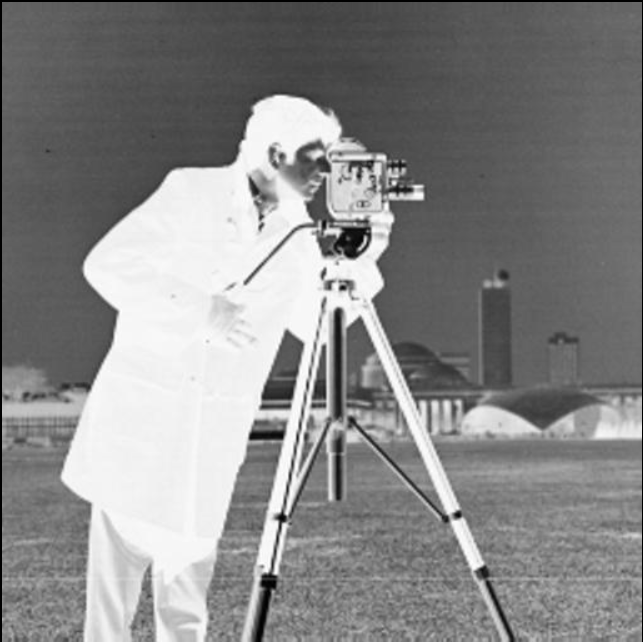

In [28]:
arr = np.asarray(image, dtype=np.uint8)
negative_arr = 255 - arr
negative_np = Image.fromarray(negative_arr)
negative_np.save('task2_1_negative_numpy.jpg')
negative_np

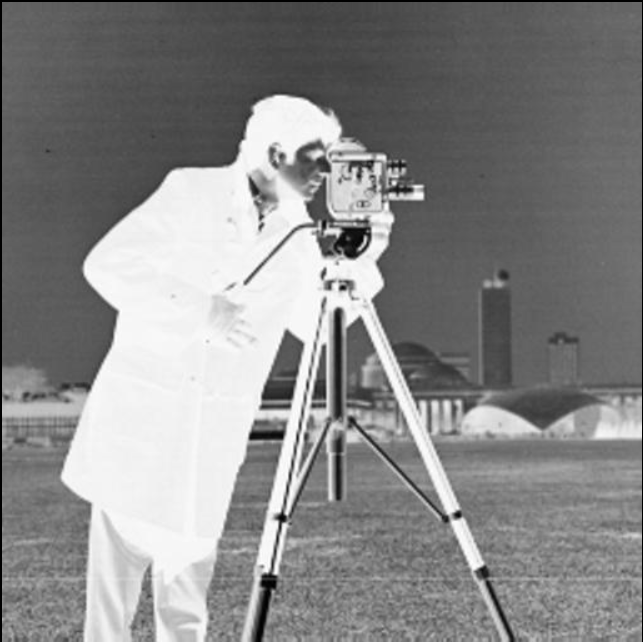

In [30]:
from PIL import ImageOps
negative_pil = ImageOps.invert(image)
negative_pil.save('task2_1_negative_pil.jpg')
negative_pil

c = 45.98590442833571


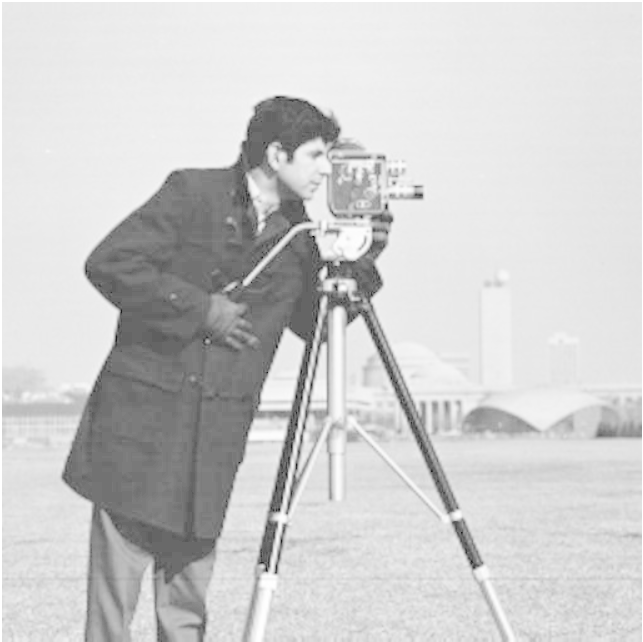

In [31]:
c = 255 / np.log(1 + 255)

arr_float = np.asarray(image, dtype=np.float32)
log_transformed_arr = c * np.log1p(arr_float)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)
log_transformed = Image.fromarray(log_transformed_arr)

log_transformed.save('task2_2_log.jpg')
print('c =', c)
log_transformed

Gamma = 0.5


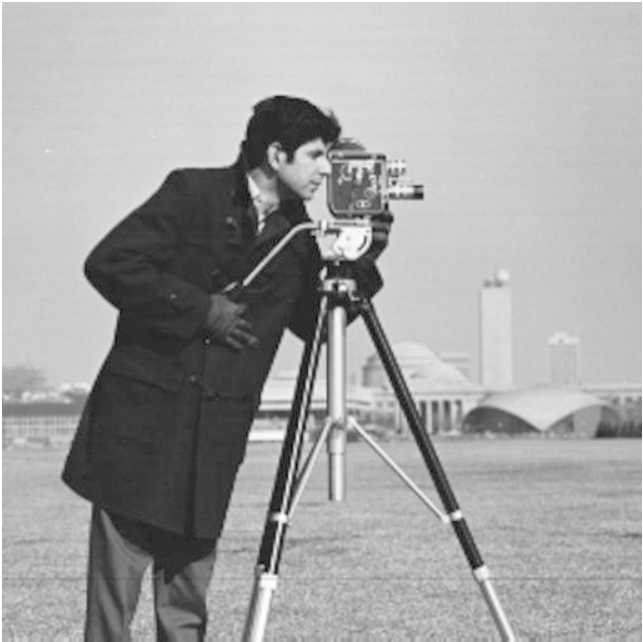

In [32]:
gamma = 0.5
arr_norm = np.asarray(image, dtype=np.float32) / 255.0
gamma_arr = 255.0 * np.power(arr_norm, gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)
gamma_image = Image.fromarray(gamma_arr)

gamma_image.save('task2_3_gamma_0_5.jpg')
print('Gamma =', gamma)
gamma_image

In [33]:
outputs = [
    'task1_1_scaled.jpg',
    'task1_1_nonuniform_scaled.jpg',
    'task1_2_rotated.jpg',
    'task1_3_sheared.jpg',
    'task2_1_negative_numpy.jpg',
    'task2_1_negative_pil.jpg',
    'task2_2_log.jpg',
    'task2_3_gamma_0_5.jpg',
]
for f in outputs:
    print(f, '✓' if Path(f).exists() else 'MISSING')

task1_1_scaled.jpg ✓
task1_1_nonuniform_scaled.jpg ✓
task1_2_rotated.jpg ✓
task1_3_sheared.jpg ✓
task2_1_negative_numpy.jpg ✓
task2_1_negative_pil.jpg ✓
task2_2_log.jpg ✓
task2_3_gamma_0_5.jpg ✓
